In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


d:\Projects\Automated-Contract-Risk-Analysis\aai\Scripts\python.exe: No module named pip


Visualization successfully saved to: D:\Projects\Automated-Contract-Risk-Analysis\legal_team\eval\evaluation_dashboard.png


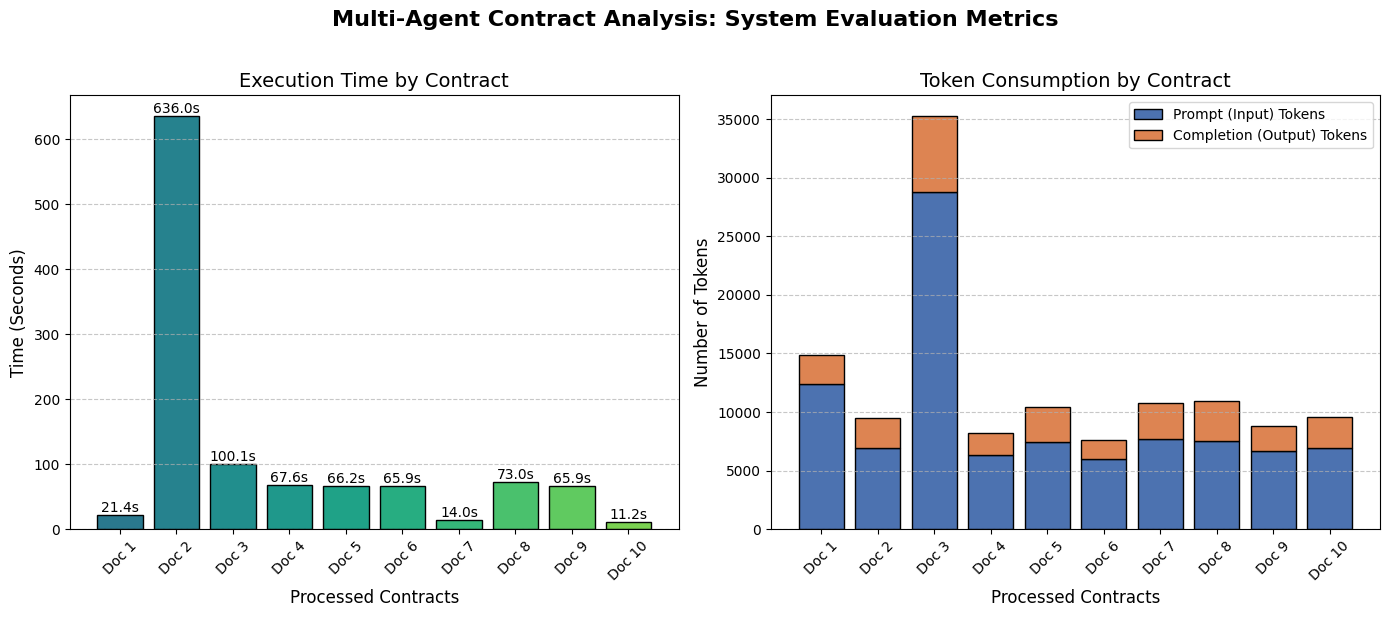

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Load the CSV Data
csv_path = "D:\\Projects\\Automated-Contract-Risk-Analysis\\legal_team\\eval\\system_evaluation_metrics.csv"

if not os.path.exists(csv_path):
    print(f"Error: Could not find {csv_path}. Please run the evaluation pipeline first.")
    exit()

df = pd.read_csv(csv_path)

# 2. Clean the Data
# Filter out any contracts that failed so they don't break the graphs
success_df = df[df['Status'] == 'Success'].copy()

# Ensure the numerical columns are actually treated as numbers
success_df['Time_Taken_Seconds'] = pd.to_numeric(success_df['Time_Taken_Seconds'])
success_df['Prompt_Tokens'] = pd.to_numeric(success_df['Prompt_Tokens'])
success_df['Completion_Tokens'] = pd.to_numeric(success_df['Completion_Tokens'])

# Create short labels for the X-axis (e.g., "Contract 1", "Contract 2") 
# to keep the chart from looking cluttered with long PDF filenames
success_df['Short_Name'] = [f"Doc {i+1}" for i in range(len(success_df))]

# 3. Set up the Matplotlib Figure (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Multi-Agent Contract Analysis: System Evaluation Metrics', fontsize=16, fontweight='bold', y=1.02)

# ==========================================
# CHART 1: Execution Time per Contract
# ==========================================
colors_time = plt.cm.viridis(np.linspace(0.4, 0.8, len(success_df)))
bars1 = ax1.bar(success_df['Short_Name'], success_df['Time_Taken_Seconds'], color=colors_time, edgecolor='black')

ax1.set_title('Execution Time by Contract', fontsize=14)
ax1.set_ylabel('Time (Seconds)', fontsize=12)
ax1.set_xlabel('Processed Contracts', fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.tick_params(axis='x', rotation=45)

# Add exact time labels on top of the bars
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{round(yval, 1)}s', ha='center', va='bottom', fontsize=10)

# ==========================================
# CHART 2: Token Consumption (Stacked Bar)
# ==========================================
# We stack Completion Tokens on top of Prompt Tokens
ax2.bar(success_df['Short_Name'], success_df['Prompt_Tokens'], label='Prompt (Input) Tokens', color='#4C72B0', edgecolor='black')
ax2.bar(success_df['Short_Name'], success_df['Completion_Tokens'], bottom=success_df['Prompt_Tokens'], label='Completion (Output) Tokens', color='#DD8452', edgecolor='black')

ax2.set_title('Token Consumption by Contract', fontsize=14)
ax2.set_ylabel('Number of Tokens', fontsize=12)
ax2.set_xlabel('Processed Contracts', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

# 4. Final Layout Adjustments and Save/Show
plt.tight_layout()

# Save the visualization as an image in your output folder
output_image = "D:\\Projects\\Automated-Contract-Risk-Analysis\\legal_team\\eval\\evaluation_dashboard.png"
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Visualization successfully saved to: {output_image}")

# Display the charts on your screen
plt.show()